# Tracking & Snelheidsanalyse (Batch) – Dataset B

Kwantificeren van de individuele snelheid en 'pace' van lopers, het opstellen van statistieken en generatie van een genormaliseerde heatmap met cameracompensatie via homografie. Deze analyse wordt uitgevoerd op basis van vooraf geëxtraheerde spatiotemporele data.

> **Vereisten:**
> - Detectiebestand `data/detecties/marathon.json` (of zelf te genereren via extractie.ipynb)
> - Lege brugafbeelding `matadibrug.png`
>
> **Output:** Inline Snelheidsstatistieken, Histogram plot en Genormaliseerde Heatmap plot.

In [3]:
import cv2
import math
import json
import numpy as np
import os
import matplotlib.pyplot as plt

print("Bibliotheken succesvol geïnstalleerd en geïmporteerd.")

# --- Globale Constanten en Configuratie ---
JSON_PATH = '../../data/detecties/marathon.json'
EMPTY_BRIDGE_PATH = '../../data/heatmap/matadibrug.png'

METERS_PER_PIXEL = 5.8 / 608

print(f"Paden geconfigureerd. Kalibratie ingesteld op {METERS_PER_PIXEL:.5f} m/pixel.")

[06/01/26 20:28:08] WARNING  Your inference package version 0.45.1 is out of date! Please upgrade to ]8;id=759377;file://C:\Users\32471\AppData\Local\Programs\Python\Python311\Lib\site-packages\inference\core\__init__.py\__init__.py]8;;\:]8;id=164399;file://C:\Users\32471\AppData\Local\Programs\Python\Python311\Lib\site-packages\inference\core\__init__.py#41\41]8;;\
                             version 1.2.12 of inference for the latest features and bug fixes by                  
                             running `pip install --upgrade inference`.                                            

ModelDependencyMissing: Your `inference` configuration does not support PaliGemma model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support Florence2 model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support Qwen2.5-VL model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[clip]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does

Bibliotheken succesvol geïnstalleerd en geïmporteerd.
Paden geconfigureerd. Kalibratie ingesteld op 0.00954 m/pixel.


## Snelheidsanalyse

In [6]:
import json
import math
import numpy as np

JSON_PATH = '../../data/detecties/marathon.json'

print(f"Start met het laden van spatiotemporele data uit: {JSON_PATH}...")

with open(JSON_PATH, 'r') as f:
    export_data = json.load(f)

fps = export_data["fps"]
runner_data = {}

# Zet de JSON data om naar het formaat dat de snelheidsanalyse verwacht
for t_id_str, track_info in export_data["tracks"].items():
    t_id = int(t_id_str)
    frames = track_info["frames"]
    x_coords = track_info["x_coords"]
    y_coords = track_info["y_coords"]

    # We hebben enkel de start- en eindpositie nodig voor de gemiddelde snelheid
    runner_data[t_id] = {
        'start_pos': (x_coords[0], y_coords[0]),
        'start_frame': frames[0],
        'end_pos': (x_coords[-1], y_coords[-1]),
        'end_frame': frames[-1]
    }

print("\n" + "="*50)
print("RESULTATEN: KINETISCHE DATA PER LOPER")
print("="*50)

valid_speeds = []

for t_id in sorted(runner_data.keys()):
    data = runner_data[t_id]
    frames_tracked = data['end_frame'] - data['start_frame']

    if frames_tracked < fps * 1.5:
        continue

    time_seconds = frames_tracked / fps
    x1, y1 = data['start_pos']
    x2, y2 = data['end_pos']

    pixel_dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    meter_dist = pixel_dist * METERS_PER_PIXEL
    speed_m_s = meter_dist / time_seconds
    speed_km_h = speed_m_s * 3.6

    valid_speeds.append(speed_km_h)

if len(valid_speeds) > 0:
    avg_speed = sum(valid_speeds) / len(valid_speeds)
    median_speed = np.median(valid_speeds)
    avg_pace_min_km = 60 / avg_speed

    print(f"\nSTATISTISCHE SAMENVATTING PELOTON")
    print(f"Gemiddelde Snelheid : {avg_speed:.2f} km/h")
    print(f"Mediaan Snelheid    : {median_speed:.2f} km/h")
    print(f"Gemiddelde Pace     : {int(avg_pace_min_km)}:{int((avg_pace_min_km - int(avg_pace_min_km)) * 60):02d} min/km")
    print(f"Unieke Lopers       : {len(valid_speeds)}")
print("="*50)

Start met het laden van spatiotemporele data uit: ../../data/detecties/marathon.json...

🏁 RESULTATEN: KINETISCHE DATA PER LOPER

📊 STATISTISCHE SAMENVATTING PELOTON
Gemiddelde Snelheid : 10.52 km/h
Mediaan Snelheid    : 10.55 km/h
Gemiddelde Pace     : 5:42 min/km
Unieke Lopers       : 270


## Snelheidshistogram

Start met het genereren van het snelheidshistogram...


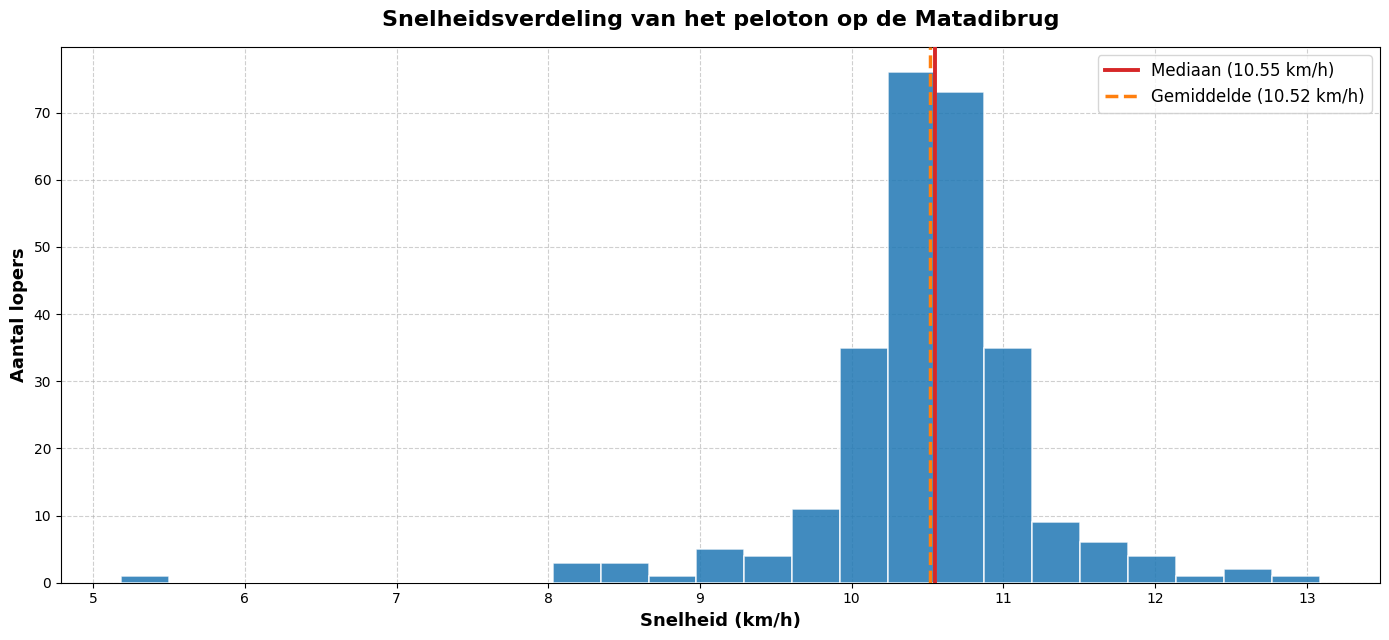

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# We gebruiken direct de valid_speeds uit de vorige cel
if 'valid_speeds' in locals() and len(valid_speeds) > 0:
    print("Start met het genereren van het snelheidshistogram...")

    snelheden = np.array(valid_speeds)
    gemiddelde = np.mean(snelheden)
    mediaan = np.median(snelheden)

    plt.figure(figsize=(14, 6.5))
    n, bins, patches = plt.hist(snelheden, bins=25, color='#1f77b4', edgecolor='white',
                                linewidth=1.1, alpha=0.85, zorder=3)

    plt.axvline(mediaan, color='#d62728', linewidth=2.8, linestyle='-', label=f'Mediaan ({mediaan:.2f} km/h)', zorder=4)
    plt.axvline(gemiddelde, color='#ff7f0e', linewidth=2.5, linestyle='--', label=f'Gemiddelde ({gemiddelde:.2f} km/h)', zorder=4)

    plt.title("Snelheidsverdeling van het peloton op de Matadibrug", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Snelheid (km/h)", fontsize=13, fontweight='bold')
    plt.ylabel("Aantal lopers", fontsize=13, fontweight='bold')
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
    plt.tight_layout()
    plt.show()
else:
    print("Geen geldige snelheidsdata gevonden om een histogram te plotten.")

## Genormaliseerde Heatmap

Start met het genereren van de genormaliseerde heatmap vanuit de JSON data...


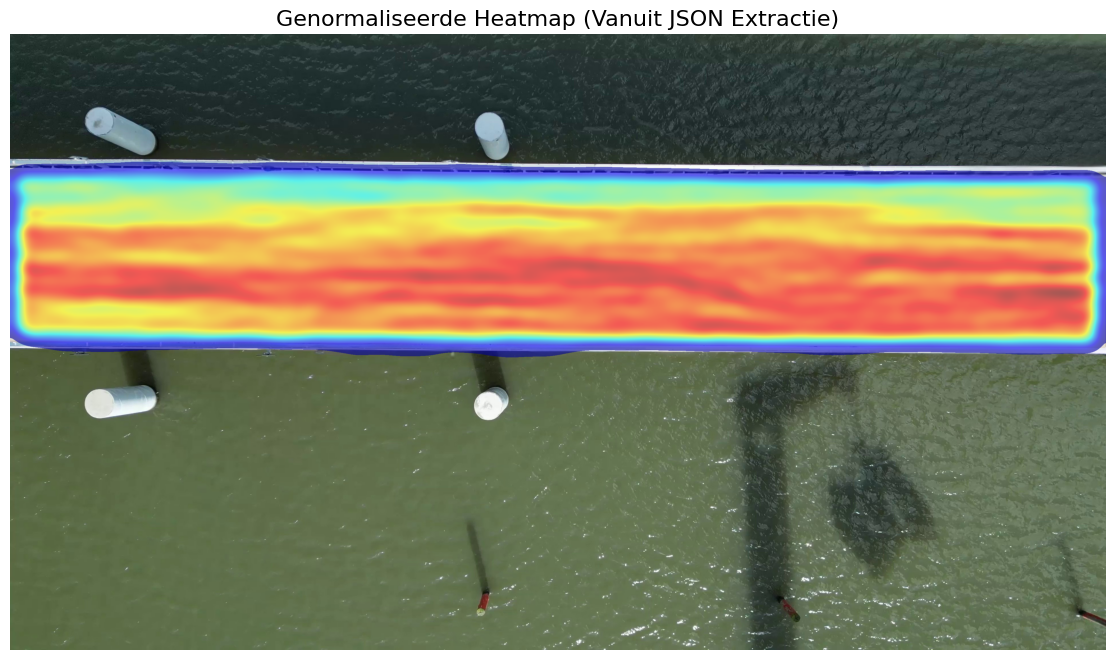

In [11]:
import cv2
import json
import numpy as np
import os
import matplotlib.pyplot as plt

print("Start met het genereren van de genormaliseerde heatmap vanuit de JSON data...")

JSON_PATH = '../../data/detecties/marathon.json'
EMPTY_BRIDGE_PATH = '../../data/heatmap/matadibrug.png'

WIDTH = 3840
HEIGHT = 2160

keyframes = {
    0:   [469, 497, 1083, 1101],
    90:  [436, 469, 1042, 1072],
    180: [587, 624, 1200, 1234],
    270: [587, 631, 1203, 1244],
    360: [594, 654, 1208, 1263],
    450: [599, 674, 1213, 1282],
    540: [564, 662, 1178, 1262],
    630: [581, 684, 1193, 1293],
    720: [556, 677, 1171, 1286],
    810: [512, 650, 1126, 1258]
}

kf_frames = list(keyframes.keys())
kf_TL = [v[0] for v in keyframes.values()]
kf_TR = [v[1] for v in keyframes.values()]
kf_BL = [v[2] for v in keyframes.values()]
kf_BR = [v[3] for v in keyframes.values()]

E_TL, E_TR, E_BL, E_BR = keyframes[0]
Y_OFFSET = -30
E_TL += Y_OFFSET
E_TR += Y_OFFSET
E_BL += Y_OFFSET
E_BR += Y_OFFSET

def get_bridge_coords(frame_idx):
    tl = np.interp(frame_idx, kf_frames, kf_TL)
    tr = np.interp(frame_idx, kf_frames, kf_TR)
    bl = np.interp(frame_idx, kf_frames, kf_BL)
    br = np.interp(frame_idx, kf_frames, kf_BR)
    return tl, tr, bl, br

# --- JSON INLEZEN IN PLAATS VAN VIDEO INFERENTIE ---
with open(JSON_PATH, 'r') as f:
    export_data = json.load(f)

runner_tracks = {}

for t_id_str, track_info in export_data["tracks"].items():
    t_id = int(t_id_str)
    frames = track_info["frames"]
    x_coords = track_info["x_coords"]
    y_bottoms = track_info["y_bottoms"]

    runner_tracks[t_id] = []

    for j in range(len(frames)):
        frame_idx = frames[j]
        x_p = x_coords[j]
        y_p = y_bottoms[j]  # Dit vervangt de bbox[3] van de video inferentie

        cur_TL, cur_TR, cur_BL, cur_BR = get_bridge_coords(frame_idx)

        y_top_current = cur_TL + (x_p / WIDTH) * (cur_TR - cur_TL)
        y_bot_current = cur_BL + (x_p / WIDTH) * (cur_BR - cur_BL)

        if y_bot_current > y_top_current:
            rel_y = (y_p - y_top_current) / (y_bot_current - y_top_current)
            y_top_empty = E_TL + (x_p / WIDTH) * (E_TR - E_TL)
            y_bot_empty = E_BL + (x_p / WIDTH) * (E_BR - E_BL)
            y_norm = y_top_empty + rel_y * (y_bot_empty - y_top_empty)

            runner_tracks[t_id].append((int(x_p), int(y_norm)))

# --- TEKENEN VAN DE HEATMAP ---
if not os.path.exists(EMPTY_BRIDGE_PATH):
    print(f"FOUT: Lege brugfoto niet gevonden op {EMPTY_BRIDGE_PATH}")
else:
    empty_img = cv2.imread(EMPTY_BRIDGE_PATH)
    heatmap_mask = np.zeros((HEIGHT, WIDTH), dtype=np.float32)

    for t_id, points in runner_tracks.items():
        if len(points) < 2:
            continue
        temp_mask = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
        for i in range(1, len(points)):
            cv2.line(temp_mask, points[i-1], points[i], 1, thickness=15)
        heatmap_mask += temp_mask

    heatmap_mask = cv2.GaussianBlur(heatmap_mask, (151, 151), 0)
    heatmap_mask = cv2.normalize(heatmap_mask, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    color_heatmap = cv2.applyColorMap(heatmap_mask, cv2.COLORMAP_JET)
    mask_indices = heatmap_mask > 5

    alpha = 0.6
    final_img = empty_img.copy()
    final_img[mask_indices] = cv2.addWeighted(color_heatmap, alpha, empty_img, 1 - alpha, 0)[mask_indices]

    final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 8))
    plt.imshow(final_img_rgb)
    plt.title("Genormaliseerde Heatmap (Vanuit JSON Extractie)", fontsize=16)
    plt.axis('off')
    plt.show()